In [3]:
import os
import pickle
import numpy as np
from google.colab import drive
drive.mount('/content/drive', force_remount=True)



# Use the same SAVE_DIR you used in regress_prf_split_expand
SAVE_DIR = "/content/drive/MyDrive/V1_Drift/repDrift_expand"


def get_zscore_suffix(to_zscore: int) -> str:
    """
    Match MATLAB zscoreStr used in regressPrfSplit_expand / regressSessionCombineRoi_expand.
    """
    if to_zscore == 1:
        return "_zscore"
    elif to_zscore == 2:
        return "_zeroMean"
    elif to_zscore == 3:
        return "_equalStd"
    elif to_zscore == 4:
        return "_zeroROImean"
    else:
        return ""


def append_mean_over_splits(arr: np.ndarray) -> np.ndarray:
    """
    Given an array with 'split' as axis 0 (shape [nsplits, ...]),
    append an extra row which is the mean over axis 0.
    """
    if arr is None:
        return None
    mean_split = np.mean(arr, axis=0, keepdims=True)
    return np.concatenate([arr, mean_split], axis=0)


def combine_rois(nsd: dict, roiPrf: dict, rois: list[int]) -> tuple[dict, dict]:
    """
    Combine multiple ROIs (e.g., V1v + V1d) into a single ROI by
    concatenating voxels along the appropriate axis.
    """
    # Fields where MATLAB used cat(2, ...)  -> concatenate along axis=1 (voxels)
    axis1_fields = [
        "sessBetas",
        "sessStdBetas",
        "pearsonRori",
        "pearsonR",
        "r2split",
        "r2oriSplit",
        "rssSplit",
        "rssOriSplit",
        "voxCoef",
        "voxOriCoef",
        "voxPredOriCoef",
        "voxOriPredOriCoef",
        "voxResidOriCoef",
        "voxOriResidOriCoef",
        "voxPredOriR2",
        "voxOriPredOriR2",
        "voxResidOriR2",
        "voxOriResidOriR2",
        "r2",
        "r2ori",
    ]

    # Fields where MATLAB used cat(1, ...) -> concatenate along axis=0 (voxels)
    axis0_fields = [
        "roiInd",
        "voxOriCoefCorrWithConst",
        "voxCoefCorrWithConst",
        "voxOriCoefCorr",
        "voxCoefCorr",
    ]

    nsd_combined = {}

    # Concatenate axis=1 fields
    for fname in axis1_fields:
        if fname not in nsd:
            continue
        arrs = [nsd[fname][roi] for roi in rois]
        if len(arrs) == 0 or arrs[0] is None:
            nsd_combined[fname] = None
        else:
            nsd_combined[fname] = np.concatenate(arrs, axis=1)

    # Concatenate axis=0 fields
    for fname in axis0_fields:
        if fname not in nsd:
            continue
        arrs = [nsd[fname][roi] for roi in rois]
        if len(arrs) == 0 or arrs[0] is None:
            nsd_combined[fname] = None
        else:
            nsd_combined[fname] = np.concatenate(arrs, axis=0)

    # ---------- Combine pRF parameters ----------
    # Use whatever keys actually exist in roiPrf (e.g. ecc, ang, sz, x, y)
    first_roi = rois[0]
    prf_keys = list(roiPrf[first_roi].keys())

    # initialize with None so we can check "is None"
    roiPrf_combined = {k: None for k in prf_keys}

    for roi in rois:
        for key in prf_keys:
            arr = np.asarray(roiPrf[roi][key])
            if roiPrf_combined[key] is None:
                roiPrf_combined[key] = arr
            else:
                roiPrf_combined[key] = np.concatenate(
                    [roiPrf_combined[key], arr], axis=0
                )

    return nsd_combined, roiPrf_combined



def regress_session_combine_roi_expand(
    isub: int,
    numregions: int = 1,
    to_zscore: int = 0,
    save_dir: str = SAVE_DIR,
):
    """
    Python version of regressSessionCombineRoi_expand.m

    Args:
        isub       : subject index (1..8)
        numregions : number of visual regions to process (1..4)
        to_zscore  : normalization flag (0..4), must match regress_prf_split_expand
        save_dir   : folder where regressPrfSplit_session_*.pkl live
    """
    save_dir = os.path.abspath(save_dir)
    zscore_str = get_zscore_suffix(to_zscore)
    print(f"\n=== regress_session_combine_roi_expand: sub {isub}, numregions={numregions}, to_zscore={to_zscore} ===")
    print("Using save_dir:", save_dir)

    # Containers across regions (index = visualRegion-1)
    allRoiPrf = []
    roiInd_list = []
    roiNsdCorr = []
    roiNsdOriCorr = []
    roiNsdOriR2 = []
    roiNsdR2 = []
    roiNsdOriRss = []
    roiNsdRss = []
    roiNsdR2within = []
    roiNsdOriR2within = []

    voxConstCoef = []
    voxConstOriCoef = []
    voxOriCoefCorrWithConst_list = []
    voxCoefCorrWithConst_list = []
    voxOriCoefCorr_list = []
    voxCoefCorr_list = []
    sessBetas_list = []
    sessStdBetas_list = []

    roiNsdOriPredOriR2 = []
    roiNsdOriResidOriR2 = []
    roiNsdPredOriR2 = []
    roiNsdResidOriR2 = []

    voxOriCoef_list = []
    voxCoef_list = []

    # Metadata (we only really have roi_names from your pkl)
    visRoiData = None
    roiNames = None
    combinedRoiNames = None
    prefAnalysis = None

    final_nsplits = None

    for iregion in range(1, numregions + 1):
        visualRegion = iregion  # V1, V2, V3, V4, ...

        in_name = f"regressPrfSplit_session_v{visualRegion}_sub{isub}{zscore_str}.pkl"
        in_path = os.path.join(save_dir, in_name)
        if not os.path.exists(in_path):
            raise FileNotFoundError(f"Missing input file: {in_path}")

        print(f"\n-- Loading {in_path}")
        with open(in_path, "rb") as f_in:
            data = pickle.load(f_in)

        nsd = data["nsd"]               # dict of dicts
        rois = data["rois"]             # list of ROI indices for this visual region
        roiPrf = data["roiPrf"]         # dict roinum -> prf dict
        nsplits = data["nsplits"]       # number of splits (sessions)
        roi_names = data.get("roi_names", None)

        # Keep roiNames for saving later
        if roiNames is None:
            roiNames = roi_names

        # ----------------------------------------------------------------
        # Combine ventral+dorsal ROIs into one (even if rois has length 1)
        # ----------------------------------------------------------------
        nsd_combined, roiPrf_combined = combine_rois(nsd, roiPrf, rois)

        # -------------- Append mean-over-splits row (nsplits+1) ---------
        for key in [
            "voxOriCoefCorrWithConst",
            "voxCoefCorrWithConst",
            "voxOriCoefCorr",
            "voxCoefCorr",
            "voxCoef",
            "voxOriCoef",
            "voxPredOriCoef",
            "voxOriPredOriCoef",
            "voxResidOriCoef",
            "voxOriResidOriCoef",
            "pearsonRori",
            "pearsonR",
            "r2",
            "r2ori",
            "r2split",
            "r2oriSplit",
            "rssSplit",
            "rssOriSplit",
            "voxPredOriR2",
            "voxOriPredOriR2",
            "voxResidOriR2",
            "voxOriResidOriR2",
        ]:
            if key in nsd_combined and nsd_combined[key] is not None:
                nsd_combined[key] = append_mean_over_splits(nsd_combined[key])

        nsplits_with_mean = nsplits + 1

        # ---------------- Extract / store region-wise values ------------

        # For convenience
        voxCoef_arr = nsd_combined["voxCoef"]            # (nsplits+1, L, P)
        voxOriCoef_arr = nsd_combined["voxOriCoef"]      # (nsplits+1, L, Pori)
        L = voxCoef_arr.shape[1]

        # Save pRF + voxel indices
        allRoiPrf.append(roiPrf_combined)
        roiInd_list.append(nsd_combined["roiInd"])

        # Split-wise & within-split metrics
        roiNsdCorr.append(nsd_combined["pearsonR"])             # (nsplits+1, L, nsplits)
        roiNsdOriCorr.append(nsd_combined["pearsonRori"])
        roiNsdOriR2.append(nsd_combined["r2oriSplit"])          # (nsplits+1, L, nsplits)
        roiNsdR2.append(nsd_combined["r2split"])
        roiNsdOriRss.append(nsd_combined["rssOriSplit"])        # (nsplits+1, L, nsplits)
        roiNsdRss.append(nsd_combined["rssSplit"])

        roiNsdR2within.append(nsd_combined["r2"])               # (nsplits+1, L)
        roiNsdOriR2within.append(nsd_combined["r2ori"])

        # Constant coefficients = last predictor
        voxConstCoef.append(voxCoef_arr[:, :, -1])              # (nsplits+1, L)
        voxConstOriCoef.append(voxOriCoef_arr[:, :, -1])        # (nsplits+1, L)

        # Coefficient correlations (with & without constant)
        voxOriCoefCorrWithConst_list.append(nsd_combined["voxOriCoefCorrWithConst"])
        voxCoefCorrWithConst_list.append(nsd_combined["voxCoefCorrWithConst"])
        voxOriCoefCorr_list.append(nsd_combined["voxOriCoefCorr"])
        voxCoefCorr_list.append(nsd_combined["voxCoefCorr"])

        # Session betas & std
        sessBetas_list.append(nsd_combined["sessBetas"])     # still per-ROI dict, but combine_rois already did concat
        sessStdBetas_list.append(nsd_combined["sessStdBetas"])

        # Pred/resid R²
        roiNsdOriPredOriR2.append(nsd_combined["voxOriPredOriR2"])
        roiNsdOriResidOriR2.append(nsd_combined["voxOriResidOriR2"])
        roiNsdPredOriR2.append(nsd_combined["voxPredOriR2"])
        roiNsdResidOriR2.append(nsd_combined["voxResidOriR2"])

        # Save all coefficients as well
        voxOriCoef_list.append(voxOriCoef_arr)
        voxCoef_list.append(voxCoef_arr)

        # Track final nsplits (with +1)
        if final_nsplits is None:
            final_nsplits = nsplits_with_mean
        else:
            assert final_nsplits == nsplits_with_mean, "nsplits mismatch across regions!"

    # --------------------------------------------------------------------
    # Save combined result (like MATLAB save(... 'regressSessCombineROI...'))
    # --------------------------------------------------------------------
    out_name = f"regressSessCombineROI_sub{isub}{zscore_str}.pkl"
    out_path = os.path.join(save_dir, out_name)

    out_dict = {
        "allRoiPrf": allRoiPrf,
        "roiNsdCorr": roiNsdCorr,
        "roiNsdOriCorr": roiNsdOriCorr,
        "roiNsdOriR2": roiNsdOriR2,
        "roiNsdR2": roiNsdR2,
        "roiNsdOriRss": roiNsdOriRss,
        "roiNsdRss": roiNsdRss,
        "numregions": numregions,
        "roiNsdResidOriR2": roiNsdResidOriR2,
        "roiNsdOriResidOriR2": roiNsdOriResidOriR2,
        "roiNsdPredOriR2": roiNsdPredOriR2,
        "roiNsdOriPredOriR2": roiNsdOriPredOriR2,
        "visRoiData": visRoiData,          # not in your pipeline; kept as None
        "roiNames": roiNames,
        "combinedRoiNames": combinedRoiNames,  # None placeholder
        "roiInd": roiInd_list,
        "prefAnalysis": prefAnalysis,      # None placeholder
        "nsplits": final_nsplits,
        "roiNsdOriR2within": roiNsdOriR2within,
        "roiNsdR2within": roiNsdR2within,
        "voxOriCoefCorrWithConst": voxOriCoefCorrWithConst_list,
        "voxCoefCorrWithConst": voxCoefCorrWithConst_list,
        "voxOriCoefCorr": voxOriCoefCorr_list,
        "voxCoefCorr": voxCoefCorr_list,
        "sessBetas": sessBetas_list,
        "sessStdBetas": sessStdBetas_list,
        "voxConstCoef": voxConstCoef,
        "voxConstOriCoef": voxConstOriCoef,
        "voxOriCoef": voxOriCoef_list,
        "voxCoef": voxCoef_list,
    }

    print(f"\nSaving combined ROI data to: {out_path}")
    with open(out_path, "wb") as f_out:
        pickle.dump(out_dict, f_out, protocol=pickle.HIGHEST_PROTOCOL)

    print("Done.")


# Example: run for subject 1, visual regions V1, V2, V3, V4, no z-scoring
regress_session_combine_roi_expand(isub=3, numregions=1, to_zscore=0)


Mounted at /content/drive

=== regress_session_combine_roi_expand: sub 3, numregions=1, to_zscore=0 ===
Using save_dir: /content/drive/MyDrive/V1_Drift/repDrift_expand

-- Loading /content/drive/MyDrive/V1_Drift/repDrift_expand/regressPrfSplit_session_v1_sub3.pkl

Saving combined ROI data to: /content/drive/MyDrive/V1_Drift/repDrift_expand/regressSessCombineROI_sub3.pkl
Done.


# check output file

(33, 1254, 32) (33, 1254, 32)
Pearson V1 (all splits, all voxels)
mean: 0.12161862
median: 0.11909047
q10/q90: [4.58493778e-05 2.48810785e-01]
R2 V1
mean: -0.19174266
median: -0.052758895
q10/q90: [-0.47938517  0.03086112]
Best voxel idx: 372 avg r: 0.2840843


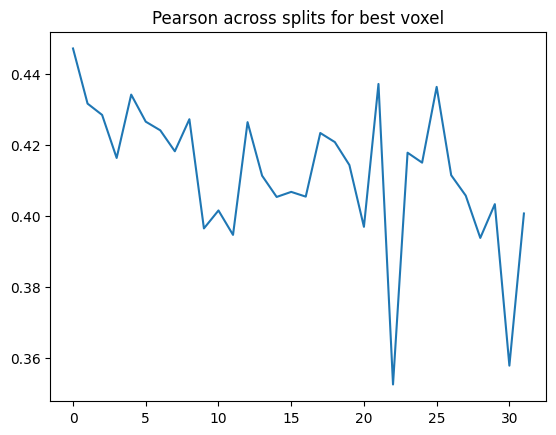

In [5]:
import numpy as np, pickle

path = "/content/drive/MyDrive/V1_Drift/repDrift_expand/regressSessCombineROI_sub3.pkl"
with open(path, "rb") as f:
    D = pickle.load(f)

roi = 0  # V1 combined
r = D["roiNsdCorr"][roi]
r_ori = D["roiNsdOriCorr"][roi]
r2 = D["roiNsdR2"][roi]
r2_ori = D["roiNsdOriR2"][roi]

print(r.shape, r2.shape)


print("Pearson V1 (all splits, all voxels)")
vals = r.flatten()
vals = vals[np.isfinite(vals)]
print("mean:", np.mean(vals))
print("median:", np.median(vals))
print("q10/q90:", np.quantile(vals, [0.1, 0.9]))


print("R2 V1")
vals = r2.flatten()
vals = vals[np.isfinite(vals)]
print("mean:", np.mean(vals))
print("median:", np.median(vals))
print("q10/q90:", np.quantile(vals, [0.1, 0.9]))

# average r across splits (exclude the last mean row)
avg_r = np.nanmean(r[:-1,:,:], axis=(0,2))  # mean over splits for each voxel
best_vox = np.argmax(avg_r)
print("Best voxel idx:", best_vox, "avg r:", avg_r[best_vox])

import matplotlib.pyplot as plt

split = 0
vox = best_vox

# Extract single-split pearson model predictions
# Load regressPrfSplit output to reconstruct exact predictions
# (but we can approximate using existing residuals)

# y_true is not saved here; we need from regressPrfSplit pkl
path.split("_session_")
subpath = f"/content/drive/MyDrive/V1_Drift/repDrift_expand/regressPrfSplit_session_v1_sub3.pkl"

with open(subpath, "rb") as f:
    S = pickle.load(f)

Y = S["nsd"]["sessBetas"][0]  # WRONG — this is session mean
# Better: load actual residuals & predictions

# BUT — easiest sanity check:
pred = r[split, vox, :]  # pearson per nextSplit
plt.plot(pred)
plt.title("Pearson across splits for best voxel")
plt.show()


In [ ]:
# pearson check
import numpy as np
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

# --- טען את הקובץ המשולב ---
path = "/content/drive/My Drive/V1_Drift/repDrift_expand/v1/Subject 3/regressSessCombineROI_sub3.npz"
D = np.load(path, allow_pickle=True)

# ----- 1. לבחור ווקסל "טוב" לפי v1_roi_r2 -----
roi_r2 = D["v1_roi_r2"]   # shape: (n_vox,)
ivox = int(np.argmax(roi_r2))   # ווקסל עם R² הגבוה ביותר
print(f"Chosen good voxel index: {ivox}, mean within-session R² = {roi_r2[ivox]:.4f}")

# ----- 2. לשלוף את מטריצות ה-CVR² וה-Pearson -----
roiNsdCorr_dict = D["roiNsdCorr"].item()   # זה dict: key=1 → visual region 1
roiNsdR2_dict   = D["roiNsdR2"].item()

corr = roiNsdCorr_dict[1]   # shape: (nsplits, nvox, nlags)
cvr2 = roiNsdR2_dict[1]     # shape: (nsplits, nvox, nlags)

nsplits, nvox, nlags = corr.shape
print(f"corr shape = {corr.shape}, cvr2 shape = {cvr2.shape}")

# ----- 3. לבחור את ה-mean split ואת ה-zero lag -----
mean_split_idx = nsplits - 1   # לפי מה שבנינו: האחרון הוא הממוצע על פני כל ה-splits

# פה צריך לקבוע איזה אינדקס הוא lag=0
# אם הלגים הם למשל: -15..+14 → אז zero lag = 15 (0-based index)
zero_lag_idx = 15   # ← אם אצלך זה 14 או משהו אחר - רק לשנות כאן

r_val   = float(corr[mean_split_idx, ivox, zero_lag_idx])
cvr2_val = float(cvr2[mean_split_idx, ivox, zero_lag_idx])

print(f"\nVoxel {ivox}, mean split, zero-lag index {zero_lag_idx}:")
print(f"  Pearson r   = {r_val:.4f}")
print(f"  r^2         = {r_val**2:.4f}")
print(f"  CVR² (from file) = {cvr2_val:.4f}")


Mounted at /content/drive
Chosen good voxel index: 591, mean within-session R² = 0.0477
corr shape = (31, 1254, 30), cvr2 shape = (31, 1254, 30)

Voxel 591, mean split, zero-lag index 15:
  Pearson r   = 0.1505
  r^2         = 0.0227
  CVR² (from file) = -0.1591
